In [1]:
import json                                                                                                                                                                                                                                          
import random
from pathlib import Path

%matplotlib inline
import matplotlib.patches as patches
import matplotlib.pyplot as plt                                                                                                                                                                                                                      
import numpy as np
import torch
import torchvision.transforms.functional as TF
from PIL import Image                                                                                                                                                                                                                                
from torch.utils.data import DataLoader, Dataset
from torchmetrics.detection import MeanAveragePrecision                                                                                                                                                                                              

In [2]:
# Manual Seed for Reproducibility
STUDENT_ID = 26045171

torch.manual_seed(STUDENT_ID)
random.seed(STUDENT_ID)                                                                                                                                                                                                               
np.random.seed(STUDENT_ID)
if torch.cuda.is_available():
    torch.cuda.manual_seed(STUDENT_ID)

DATASET_ROOT = Path("26045171/Object_Detection/coco")
RUNS_DIR     = Path("runs/exp3_fasterrcnn_v2")
RUNS_DIR.mkdir(parents=True, exist_ok=True)

# torchvision reserves class index 0 for background, so our 5 lettuce                                                                                                                                                                                
# classes map to indices 1–5, which conveniently matches COCO's 1-indexed IDs.
CLASS_NAMES = ["__background__", "Ready", "empty_pod", "germination", "pod", "young"]                                                                                                                                                                
NUM_CLASSES = len(CLASS_NAMES)  # 6
                                                                                                                                                                                                                                                   
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE} | Classes: {NUM_CLASSES}")

Device: cuda | Classes: 6


In [3]:
class LettuceDataset(Dataset):
    def __init__(self, img_dir, ann_file):                                                                                                                                                                                            
        self.img_dir = Path(img_dir)

        with open(ann_file) as f:                                                                                                                                                                                                                    
            coco = json.load(f)
                                                                                                                                                                                                                                       
        # Create image_id to annotations dictionary for efficient lookup in __getitem__
        self.ann_by_img = {}
        for ann in coco["annotations"]:                                                                                                                                                                                                              
            self.ann_by_img.setdefault(ann["image_id"], []).append(ann)

        self.images = []
        self.unannotated_count = 0

        # Keep images that have annotations
        # Report unannotated images for debugging
        for img in coco["images"]:
            if img["id"] in self.ann_by_img:
                self.images.append(img)
            else:
                self.unannotated_count += 1

    def details(self):
        return f"With annotations: {len(self.images):<4} | Unannotated: {self.unannotated_count:<4}"

    def __len__(self):                                                                                                                                                                                                                               
        return len(self.images)

    def __getitem__(self, idx):
        img_metadata = self.images[idx]
        img  = Image.open(self.img_dir / img_metadata["file_name"]).convert("RGB")                                                                                                                                                                           
                                                                                                                                                                                                                 
        boxes, labels = [], []
        for ann in self.ann_by_img[img_metadata["id"]]:                                                                                                                                                                                                      
            x, y, w, h = ann["bbox"]

            if w <= 0 or h <= 0 or ann["category_id"] not in range(1, NUM_CLASSES):                                                                                                                                                                                                                     
                continue  # skip malformed annotations and invalid category IDs

            # Convert COCO [x, y, w, h] to [x1, y1, x2, y2]                                                                                                                                                                                           
            boxes.append([x, y, x + w, y + h])
            labels.append(ann["category_id"])

        target = {                                                                                                                                                                                                                                   
            "boxes":    torch.as_tensor(boxes,  dtype=torch.float32),                                                                                                                                                                                
            "labels":   torch.as_tensor(labels, dtype=torch.int64),
            "image_id": torch.tensor([img_metadata["id"]]),                                                                                                                                                                                                  
        }

        img = TF.to_tensor(img)
   
        return img, target

In [4]:
def collate_fn(batch):                                                                                                                                                                                                                               
    return tuple(zip(*batch))                                                                                                                                                                                                                        

train_ds = LettuceDataset(DATASET_ROOT / "train", DATASET_ROOT / "train" / "train_annotations.json")                                                                                                                                                                                                              
val_ds   = LettuceDataset(DATASET_ROOT / "valid", DATASET_ROOT / "valid" / "valid_annotations.json")                                                                                                                                                                         
test_ds  = LettuceDataset(DATASET_ROOT / "test", DATASET_ROOT / "test"  / "test_annotations.json")

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, collate_fn=collate_fn, num_workers=8, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, collate_fn=collate_fn, num_workers=8, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False, collate_fn=collate_fn, num_workers=8, pin_memory=True)

print(f"TRAIN:      | {train_ds.details()}")
print(f"VALIDATION: | {val_ds.details()}")
print(f"TEST:       | {test_ds.details()}")

TRAIN:      | With annotations: 1050 | Unannotated: 7   
VALIDATION: | With annotations: 224  | Unannotated: 2   
TEST:       | With annotations: 226  | Unannotated: 0   


In [5]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def build_faster_rcnn(num_classes):
    # Load Faster-RCNN with a ResNet-50 + FPN backbone pretrained on COCO.
    weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT                                                                                                                                                                           
    model = fasterrcnn_resnet50_fpn(weights=weights)                                                                                                                                                                                           

    # Get the number of input features for the classifier head
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # The pretrained head predicts 91 COCO classes.
    # We replace it with a new one for our 6 classes.                                                                                                                                                                            
    # The backbone weights are kept and will be fine-tuned on our data.
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)                                                                                                                                                                      
                                                                                                                                                                                                                           
    return model

model = build_faster_rcnn(NUM_CLASSES).to(DEVICE)

In [6]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    running_loss = 0.0
    total_images = 0

    for images, targets in loader:
        images  = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss      = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * len(images)
        total_images += len(images)

    return running_loss / total_images # Calculate mean instance loss over the epoch

In [7]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    metric = MeanAveragePrecision(iou_type="bbox", class_metrics=True)
    for images, targets in loader:
        images = [img.to(DEVICE) for img in images]
        preds  = model(images)

        filtered = []
        for pred in preds:
            keep = pred["scores"] > 0.05 # Filter out predictions with low confidence scores
            filtered.append({
                "boxes":  pred["boxes"][keep],
                "labels": pred["labels"][keep],
                "scores": pred["scores"][keep],
            })

        metric.update(
            [{k: v.cpu() for k, v in p.items()} for p in filtered],  # score-filtered model outputs
            [{k: v.cpu() for k, v in t.items()} for t in targets],   # ground-truth boxes & labels
        )
    return metric.compute()

In [8]:
@torch.no_grad()
def compute_val_loss(model, loader):
    model.train()  # training mode so the model returns a loss dict instead of predictions
    total_loss   = 0.0
    total_images = 0

    for images, targets in loader:
        images  = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        total_loss   += sum(loss_dict.values()).item() * len(images)
        total_images += len(images)

    return total_loss / total_images # Calculate mean instance loss over the epoch

In [9]:
from torchvision.models.detection import ssd300_vgg16, SSD300_VGG16_Weights
from torchvision.models.detection.ssd import SSDClassificationHead

# All constants (CLASS_NAMES, NUM_CLASSES, DEVICE, STUDENT_ID) are shared
# with Exp 3 — reuse them from the earlier cells.

SSD_RUNS_DIR = Path("runs/exp4_ssd_v2")
SSD_RUNS_DIR.mkdir(parents=True, exist_ok=True)

def build_ssd(num_classes):
    # SSD300 pretrained on COCO 2017 — same pretraining dataset as Faster-RCNN,
    # making the comparison fair in terms of prior knowledge given to each model.
    weights = SSD300_VGG16_Weights.DEFAULT
    model   = ssd300_vgg16(weights=weights)

    # Replace only the classification head for our number of classes.
    # The backbone and box regression head keep their COCO pretrained weights.
    in_channels = [c.in_channels for c in model.head.classification_head.module_list]
    num_anchors = model.anchor_generator.num_anchors_per_location()
    model.head.classification_head = SSDClassificationHead(
        in_channels, num_anchors, num_classes
    )

    return model

ssd_model = build_ssd(NUM_CLASSES).to(DEVICE)

total     = sum(p.numel() for p in ssd_model.parameters())
trainable = sum(p.numel() for p in ssd_model.parameters() if p.requires_grad)
print(f"Total params:     {total:,}")
print(f"Trainable params: {trainable:,}")

Total params:     24,280,556
Trainable params: 24,241,836


In [10]:
# Same dataset class as Faster-RCNN — no manual resizing needed since SSD300
# resizes all images internally to 300×300 via GeneralizedRCNNTransform.
# Batch=64 is justified by SSD's fixed small input (300×300 vs Faster-RCNN's
# ~800×1333) — the smaller resolution fits more images in GPU memory.
# Faster-RCNN at batch=4 and SSD at batch=64 are each at their practical
# optimum; the different batch sizes do not make the comparison unfair.

ssd_train_ds = LettuceDataset(DATASET_ROOT / "train", DATASET_ROOT / "train" / "train_annotations.json")
ssd_val_ds   = LettuceDataset(DATASET_ROOT / "valid", DATASET_ROOT / "valid" / "valid_annotations.json")
ssd_test_ds  = LettuceDataset(DATASET_ROOT / "test", DATASET_ROOT / "test"  / "test_annotations.json")

ssd_train_loader = DataLoader(ssd_train_ds, batch_size=64, collate_fn=collate_fn, num_workers=8, pin_memory=True)
ssd_val_loader   = DataLoader(ssd_val_ds,   batch_size=64, collate_fn=collate_fn, num_workers=8, pin_memory=True)
ssd_test_loader  = DataLoader(ssd_test_ds,  batch_size=64, collate_fn=collate_fn, num_workers=8, pin_memory=True)

## 1. Training

### 1.1 Faster R-CNN

In [11]:
optimizer = torch.optim.SGD(
    model.parameters(), lr=1e-3, momentum=0.9, weight_decay=5e-4
)

EPOCHS   = 300
PATIENCE = 30

best_map       = 0.0
patience_counter = 0
history = {"train_loss": [], "val_loss": [], "val_map": []}

for epoch in range(1, EPOCHS + 1):
    train_loss  = train_one_epoch(model, train_loader, optimizer)
    val_loss    = compute_val_loss(model, val_loader)
    val_metrics = evaluate(model, val_loader)

    val_map = val_metrics["map"].item()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_map"].append(val_map)

    print(f"Epoch {epoch:3d}/{EPOCHS}  "
          f"loss={train_loss:.4f}/{val_loss:.4f}  "
          f"mAP@50-95={val_map:.4f}")

    if val_map > best_map:
        best_map = val_map
        patience_counter = 0
        torch.save(model.state_dict(), RUNS_DIR / "best.pth")
        print(f"  → Best saved (mAP@50-95={best_map:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping — no improvement for {PATIENCE} epochs.")
            break


Epoch   1/300  loss=1.3948/0.9316  mAP@50-95=0.2530
  → Best saved (mAP@50-95=0.2530)
Epoch   2/300  loss=0.8097/0.6793  mAP@50-95=0.4045
  → Best saved (mAP@50-95=0.4045)
Epoch   3/300  loss=0.6490/0.6052  mAP@50-95=0.4851
  → Best saved (mAP@50-95=0.4851)
Epoch   4/300  loss=0.5782/0.5438  mAP@50-95=0.5467
  → Best saved (mAP@50-95=0.5467)
Epoch   5/300  loss=0.5311/0.5148  mAP@50-95=0.5694
  → Best saved (mAP@50-95=0.5694)
Epoch   6/300  loss=0.5000/0.4996  mAP@50-95=0.5875
  → Best saved (mAP@50-95=0.5875)
Epoch   7/300  loss=0.4792/0.4874  mAP@50-95=0.5972
  → Best saved (mAP@50-95=0.5972)
Epoch   8/300  loss=0.4656/0.4797  mAP@50-95=0.6057
  → Best saved (mAP@50-95=0.6057)
Epoch   9/300  loss=0.4495/0.4661  mAP@50-95=0.6106
  → Best saved (mAP@50-95=0.6106)
Epoch  10/300  loss=0.4308/0.4618  mAP@50-95=0.6138
  → Best saved (mAP@50-95=0.6138)
Epoch  11/300  loss=0.4182/0.4646  mAP@50-95=0.6277
  → Best saved (mAP@50-95=0.6277)
Epoch  12/300  loss=0.4107/0.4410  mAP@50-95=0.6328
  

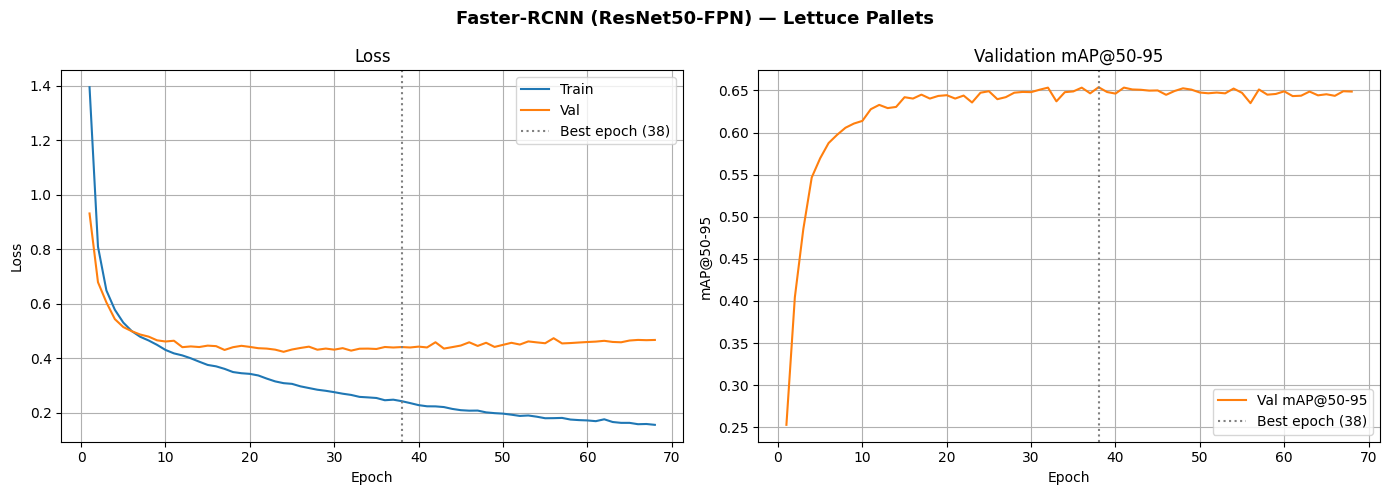

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_x   = range(1, len(history["train_loss"]) + 1)
best_epoch = int(np.argmax(history["val_map"])) + 1

ax1.plot(epochs_x, history["train_loss"], label="Train", color="tab:blue")
ax1.plot(epochs_x, history["val_loss"],   label="Val",   color="tab:orange")
ax1.axvline(best_epoch, color="grey", linestyle=":", lw=1.5, label=f"Best epoch ({best_epoch})")
ax1.set(xlabel="Epoch", ylabel="Loss", title="Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_x, history["val_map"], label="Val mAP@50-95", color="tab:orange")
ax2.axvline(best_epoch, color="grey", linestyle=":", lw=1.5, label=f"Best epoch ({best_epoch})")
ax2.set(xlabel="Epoch", ylabel="mAP@50-95", title="Validation mAP@50-95")
ax2.legend()
ax2.grid(True)

plt.suptitle("Faster-RCNN (ResNet50-FPN) — Lettuce Pallets", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(RUNS_DIR / "training_curves.png", dpi=150)
plt.show()

### 1.2 SSD300

In [13]:
ssd_optimizer = torch.optim.SGD(
    ssd_model.parameters(), lr=1e-3, momentum=0.9, weight_decay=5e-4
)

EPOCHS   = 300
PATIENCE = 30

best_map       = 0.0
patience_counter = 0
ssd_history = {"train_loss": [], "val_loss": [], "val_map": []}

for epoch in range(1, EPOCHS + 1):
    train_loss  = train_one_epoch(ssd_model, ssd_train_loader, ssd_optimizer)
    val_loss    = compute_val_loss(ssd_model, ssd_val_loader)
    val_metrics = evaluate(ssd_model, ssd_val_loader)

    val_map = val_metrics["map"].item()

    ssd_history["train_loss"].append(train_loss)
    ssd_history["val_loss"].append(val_loss)
    ssd_history["val_map"].append(val_map)

    print(f"Epoch {epoch:3d}/{EPOCHS}  "
          f"loss={train_loss:.4f}/{val_loss:.4f}  "
          f"mAP@50-95={val_map:.4f}")

    if val_map > best_map:
        best_map = val_map
        patience_counter = 0
        torch.save(ssd_model.state_dict(), SSD_RUNS_DIR / "best.pth")
        print(f"  → Best saved (mAP@50-95={best_map:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping — no improvement for {PATIENCE} epochs.")
            break

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


Epoch   1/300  loss=9.4464/7.4392  mAP@50-95=0.0184
  → Best saved (mAP@50-95=0.0184)
Epoch   2/300  loss=6.3476/5.1182  mAP@50-95=0.0608
  → Best saved (mAP@50-95=0.0608)
Epoch   3/300  loss=4.5982/4.1176  mAP@50-95=0.1283
  → Best saved (mAP@50-95=0.1283)
Epoch   4/300  loss=3.9370/3.7263  mAP@50-95=0.2114
  → Best saved (mAP@50-95=0.2114)
Epoch   5/300  loss=3.6184/3.4902  mAP@50-95=0.2625
  → Best saved (mAP@50-95=0.2625)
Epoch   6/300  loss=3.4089/3.3291  mAP@50-95=0.3019
  → Best saved (mAP@50-95=0.3019)
Epoch   7/300  loss=3.2411/3.1916  mAP@50-95=0.3317
  → Best saved (mAP@50-95=0.3317)
Epoch   8/300  loss=3.1002/3.0759  mAP@50-95=0.3587
  → Best saved (mAP@50-95=0.3587)
Epoch   9/300  loss=2.9932/2.9883  mAP@50-95=0.3843
  → Best saved (mAP@50-95=0.3843)
Epoch  10/300  loss=2.8961/2.9125  mAP@50-95=0.4037
  → Best saved (mAP@50-95=0.4037)
Epoch  11/300  loss=2.7939/2.8304  mAP@50-95=0.4274
  → Best saved (mAP@50-95=0.4274)
Epoch  12/300  loss=2.7037/2.7562  mAP@50-95=0.4477
  

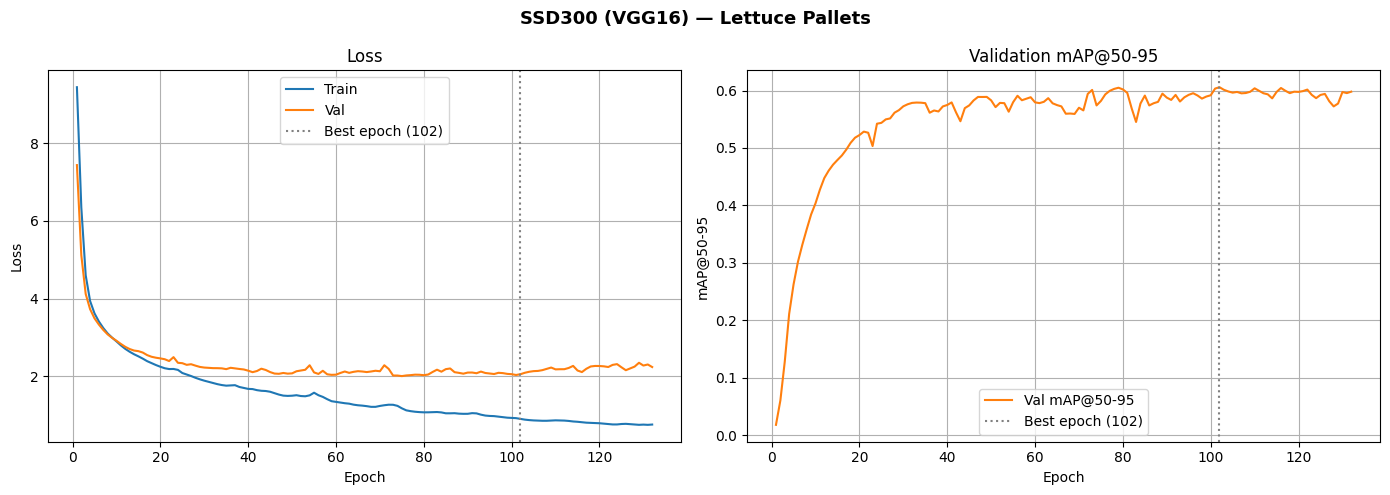

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_x   = range(1, len(ssd_history["train_loss"]) + 1)
best_epoch = int(np.argmax(ssd_history["val_map"])) + 1

ax1.plot(epochs_x, ssd_history["train_loss"], label="Train", color="tab:blue")
ax1.plot(epochs_x, ssd_history["val_loss"],   label="Val",   color="tab:orange")
ax1.axvline(best_epoch, color="grey", linestyle=":", lw=1.5, label=f"Best epoch ({best_epoch})")
ax1.set(xlabel="Epoch", ylabel="Loss", title="Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_x, ssd_history["val_map"], label="Val mAP@50-95", color="tab:orange")
ax2.axvline(best_epoch, color="grey", linestyle=":", lw=1.5, label=f"Best epoch ({best_epoch})")
ax2.set(xlabel="Epoch", ylabel="mAP@50-95", title="Validation mAP@50-95")
ax2.legend()
ax2.grid(True)

plt.suptitle("SSD300 (VGG16) — Lettuce Pallets", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SSD_RUNS_DIR / "training_curves.png", dpi=150)
plt.show()

## 2. Evaluation

### 2.1 Faster R-CNN — Train / Val / Test

In [15]:
model.load_state_dict(torch.load(RUNS_DIR / "best.pth", map_location=DEVICE))

print("=== FASTER-RCNN (ResNet-50 FPN) ===")
for split, loader in [("Train", train_loader), ("Val", val_loader), ("Test", test_loader)]:
    m = evaluate(model, loader)
    print(f"\n{split}:")
    print(f"  mAP@50:    {m['map_50'].item():.4f}")
    print(f"  mAP@50-95: {m['map'].item():.4f}")
    print(f"  Recall:    {m['mar_100'].item():.4f}")
    if split == "Test":
        print("\n  Per-class mAP@50-95:")
        for name, ap in zip(CLASS_NAMES[1:], m["map_per_class"]):
            print(f"    {name:15s}: {ap:.4f}")
        test_metrics = m

=== FASTER-RCNN (ResNet-50 FPN) ===

Train:
  mAP@50:    0.9914
  mAP@50-95: 0.7982
  Recall:    0.8486

Val:
  mAP@50:    0.9317
  mAP@50-95: 0.6538
  Recall:    0.7364

Test:
  mAP@50:    0.9362
  mAP@50-95: 0.6588
  Recall:    0.7387

  Per-class mAP@50-95:
    Ready          : 0.4695
    empty_pod      : 0.7255
    germination    : 0.7295
    pod            : 0.7388
    young          : 0.6308


### 2.2 SSD300 — Train / Val / Test

In [16]:
ssd_model.load_state_dict(torch.load(SSD_RUNS_DIR / "best.pth", map_location=DEVICE))

print("=== SSD300 (VGG16) ===")
for split, loader in [("Train", ssd_train_loader), ("Val", ssd_val_loader), ("Test", ssd_test_loader)]:
    m = evaluate(ssd_model, loader)
    print(f"\n{split}:")
    print(f"  mAP@50:    {m['map_50'].item():.4f}")
    print(f"  mAP@50-95: {m['map'].item():.4f}")
    print(f"  Recall:    {m['mar_100'].item():.4f}")
    if split == "Test":
        print("\n  Per-class mAP@50-95:")
        for name, ap in zip(CLASS_NAMES[1:], m["map_per_class"]):
            print(f"    {name:15s}: {ap:.4f}")
        ssd_test_metrics = m

=== SSD300 (VGG16) ===

Train:
  mAP@50:    0.9834
  mAP@50-95: 0.7673
  Recall:    0.8155

Val:
  mAP@50:    0.9065
  mAP@50-95: 0.6057
  Recall:    0.7032

Test:
  mAP@50:    0.9011
  mAP@50-95: 0.5992
  Recall:    0.6961

  Per-class mAP@50-95:
    Ready          : 0.4514
    empty_pod      : 0.6295
    germination    : 0.6612
    pod            : 0.6893
    young          : 0.5647


### 2.3 Faster R-CNN vs SSD300

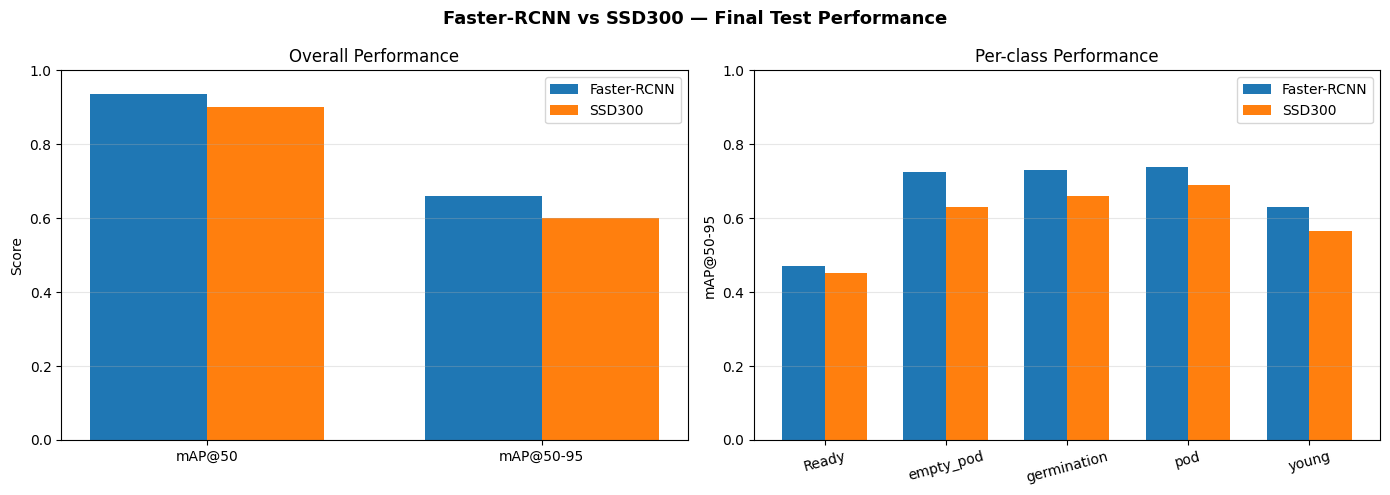

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
width = 0.35

# Overall mAP
metrics_labels = ["mAP@50", "mAP@50-95"]
frcnn_overall  = [test_metrics["map_50"].item(), test_metrics["map"].item()]
ssd_overall    = [ssd_test_metrics["map_50"].item(), ssd_test_metrics["map"].item()]

x = np.arange(len(metrics_labels))
axes[0].bar(x - width/2, frcnn_overall, width, label="Faster-RCNN", color="tab:blue")
axes[0].bar(x + width/2, ssd_overall,   width, label="SSD300",      color="tab:orange")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_labels)
axes[0].set_ylabel("Score")
axes[0].set_title("Overall Performance")
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(True, axis="y", alpha=0.3)

# Per-class mAP@50-95
frcnn_per_class = test_metrics["map_per_class"].tolist()
ssd_per_class   = ssd_test_metrics["map_per_class"].tolist()
x = np.arange(len(CLASS_NAMES[1:]))
axes[1].bar(x - width/2, frcnn_per_class, width, label="Faster-RCNN", color="tab:blue")
axes[1].bar(x + width/2, ssd_per_class,   width, label="SSD300",      color="tab:orange")
axes[1].set_xticks(x)
axes[1].set_xticklabels(CLASS_NAMES[1:], rotation=15)
axes[1].set_ylabel("mAP@50-95")
axes[1].set_title("Per-class Performance")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, axis="y", alpha=0.3)

plt.suptitle("Faster-RCNN vs SSD300 — Final Test Performance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("runs/comparison.png", dpi=150)
plt.show()

### 2.4 Prediction Analysis

In [18]:
@torch.no_grad()
def plot_class_predictions(models_dict, dataset, class_name, n=3, conf=0.3, seed=STUDENT_ID):
    class_idx = CLASS_NAMES.index(class_name)
    colors    = plt.cm.Set1(np.linspace(0, 1, NUM_CLASSES))

    candidates = [i for i in range(len(dataset))
                  if class_idx in dataset[i][1]["labels"].tolist()]
    random.seed(seed)
    indices = random.sample(candidates, min(n, len(candidates)))

    n_cols = len(models_dict) + 1  # ground truth + one col per model
    fig, axes = plt.subplots(n, n_cols, figsize=(6 * n_cols, 5 * n))
    if n == 1:
        axes = axes[np.newaxis, :]

    for row, idx in enumerate(indices):
        img_tensor, target = dataset[idx]

        # Ground truth column
        ax = axes[row, 0]
        ax.imshow(img_tensor.permute(1, 2, 0).numpy())
        for box, label in zip(target["boxes"], target["labels"]):
            x1, y1, x2, y2 = box.tolist()
            cls = label.item()
            ax.add_patch(patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor=colors[cls], facecolor="none"
            ))
            ax.text(x1, y1 - 4, CLASS_NAMES[cls],
                    color=colors[cls], fontsize=7, fontweight="bold")
        ax.set_title("Ground Truth", fontsize=9)
        ax.axis("off")

        # One column per model
        for col, (model_name, m) in enumerate(models_dict.items(), start=1):
            m.eval()
            pred = m([img_tensor.to(DEVICE)])[0]
            ax   = axes[row, col]
            ax.imshow(img_tensor.permute(1, 2, 0).numpy())
            for box, label, score in zip(pred["boxes"], pred["labels"], pred["scores"]):
                if score < conf:
                    continue
                x1, y1, x2, y2 = box.cpu().tolist()
                cls = label.item()
                ax.add_patch(patches.Rectangle(
                    (x1, y1), x2 - x1, y2 - y1,
                    linewidth=2, edgecolor=colors[cls], facecolor="none"
                ))
                ax.text(x1, y1 - 4, f"{CLASS_NAMES[cls]} {score:.2f}",
                        color=colors[cls], fontsize=7, fontweight="bold")
            ax.set_title(model_name, fontsize=9)
            ax.axis("off")

    plt.suptitle(f"'{class_name}' — Ground Truth vs Predictions (conf \u2265 {conf})",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

#### 2.4.1 Difficult classes — 'Ready' (lowest AP for both models)

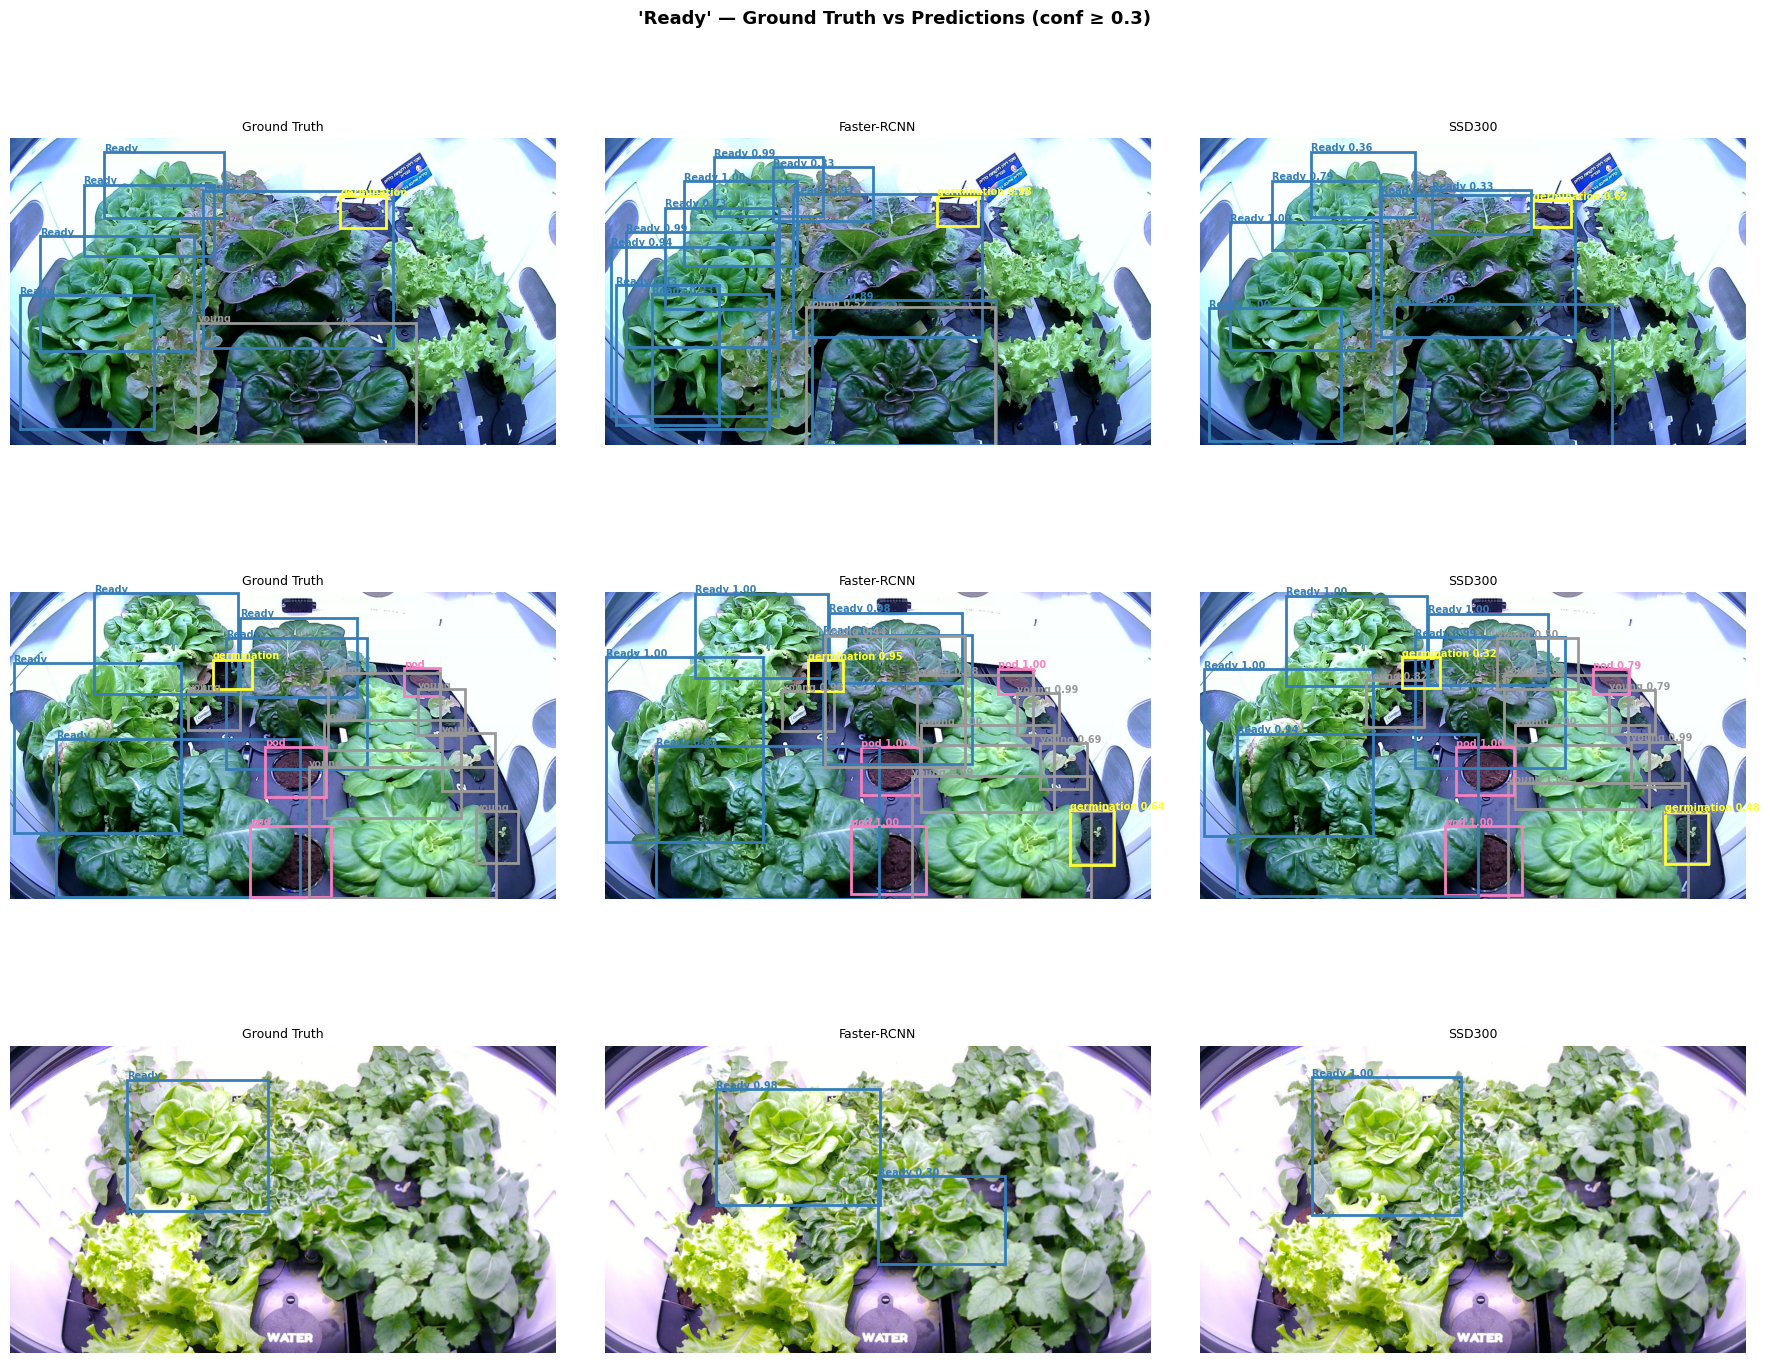

In [19]:
# 'Ready' has the lowest AP for both models (FRCNN ~0.46, SSD ~0.48)
plot_class_predictions(
    {"Faster-RCNN": model, "SSD300": ssd_model},
    test_ds, "Ready", n=3
)

#### 2.4.2 Performance gap — 'empty_pod' (largest gap between models)

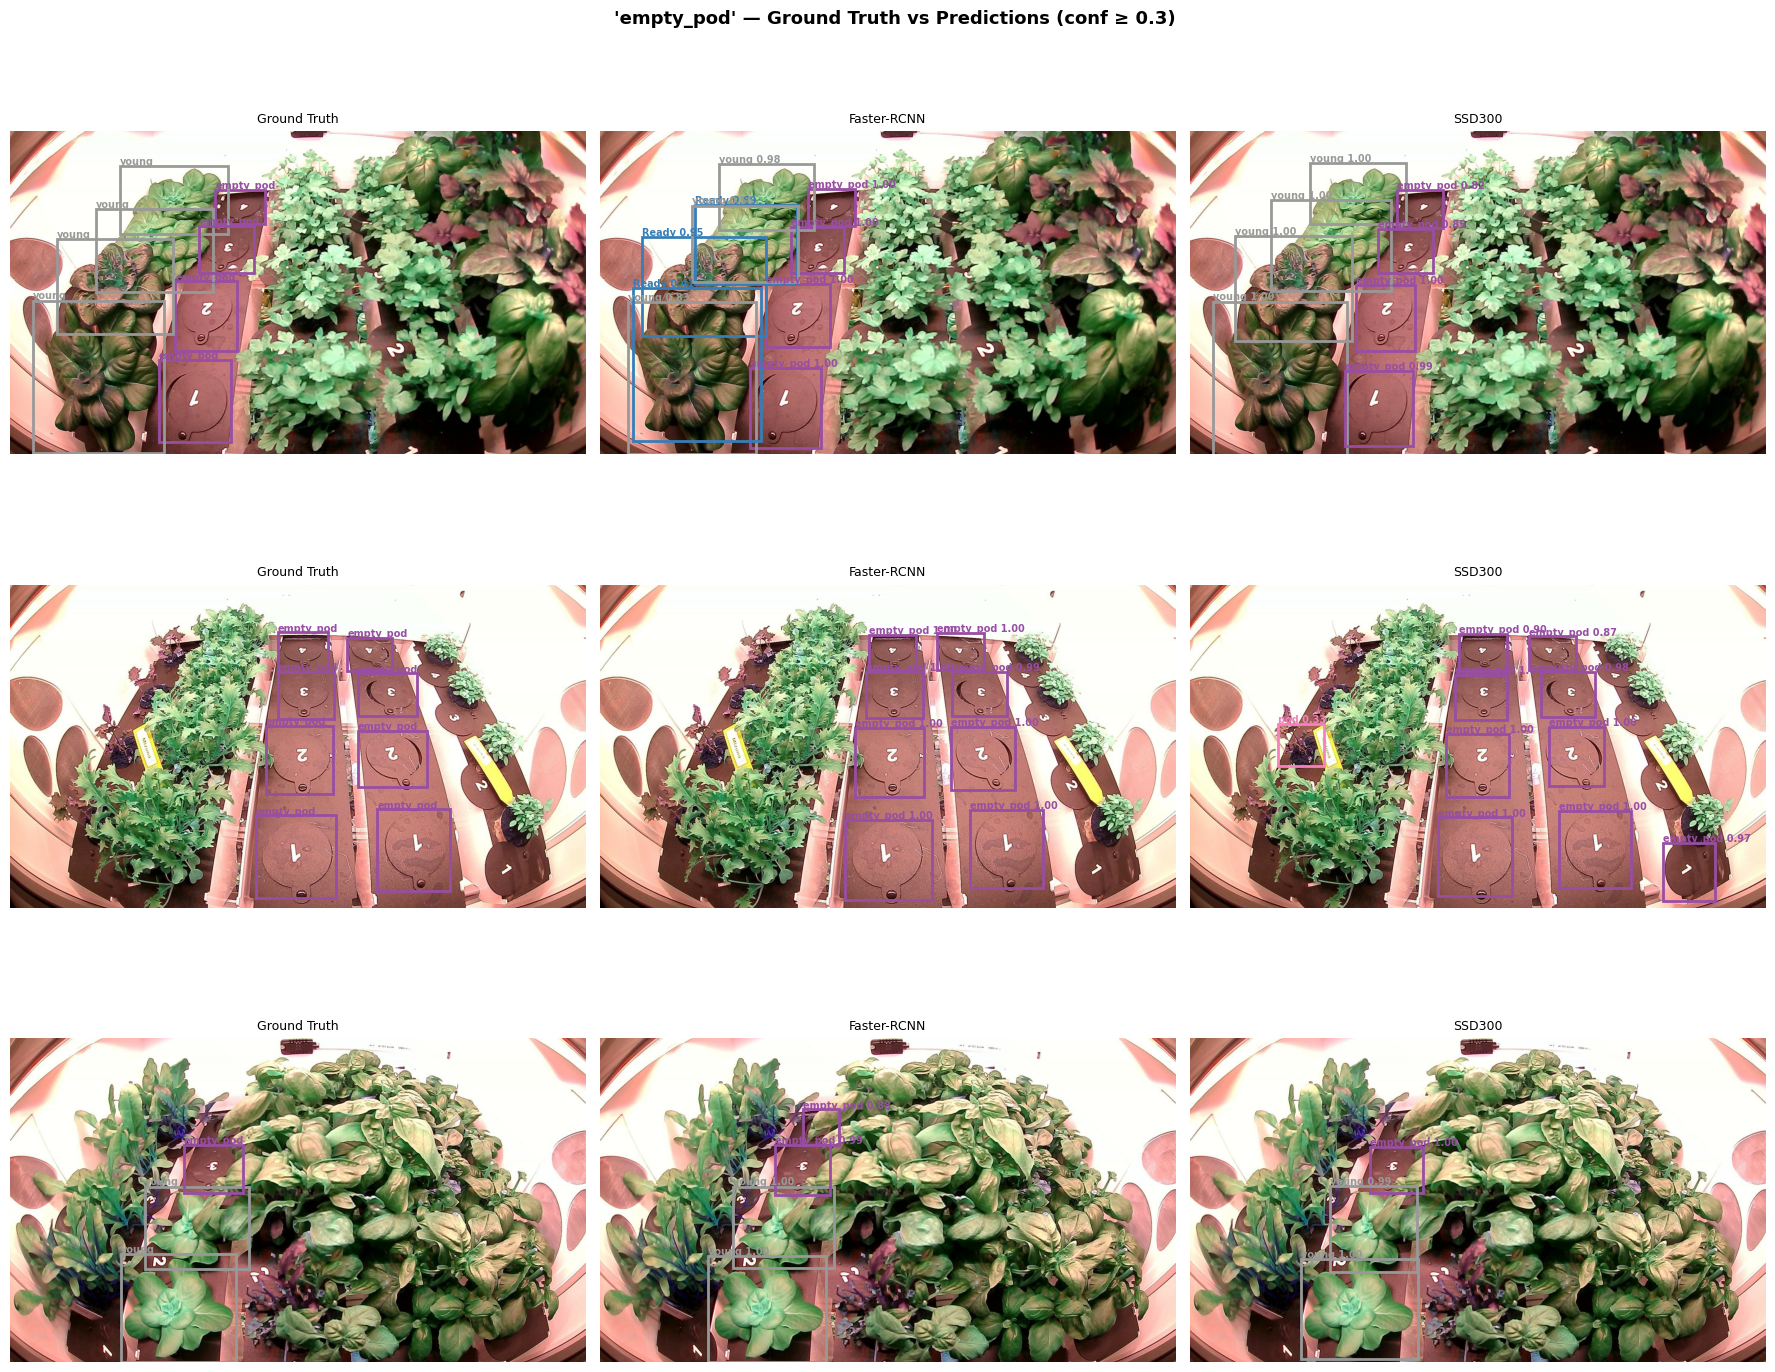

In [20]:
# 'empty_pod' shows the largest per-class gap between models (FRCNN ~0.72, SSD ~0.64)
plot_class_predictions(
    {"Faster-RCNN": model, "SSD300": ssd_model},
    test_ds, "empty_pod", n=3
)